# Laboratorio 8 — Deep Learning
## Task 1 y Task 2: Mini-GPT con muestreo controlado sobre `tiny_shakespeare`

Se extiende el Mini-GPT de la Semana 6 (`Transformer_desde_cero`). Se **reutiliza** de ese proyecto:
`layer_norm`, `make_positional_encoding`, la lógica de `multi_head_attention` con máscara causal y el uso de tensores/`nn.Parameter` puros (sin `nn.MultiheadAttention`).
Cambios respecto a la Semana 6: (i) vocabulario a nivel de **carácter**, (ii) procesamiento por **batches** `(B, T, d)`, (iii) **3 capas** de decoder, (iv) evaluación con perplejidad y (v) tres estrategias de muestreo.

In [1]:
import math, random, urllib.request, os, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
torch.set_num_threads(os.cpu_count())
device = 'cpu'
print('PyTorch', torch.__version__)

PyTorch 2.13.0+cpu


## Task 1.1 — Dataset, vocabulario y batches

In [2]:
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
if not os.path.exists('input.txt'):
    urllib.request.urlretrieve(URL, 'input.txt')
text = open('input.txt', encoding='utf-8').read()
print('Caracteres totales:', len(text))

# Vocabulario de caracteres únicos y mappings bidireccionales char <-> índice
chars = sorted(set(text))
V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
assert V == 65, V
print('Tamaño del vocabulario:', V)
print(repr(''.join(chars)))

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[int(i)] for i in ids)

# Codificar todo el texto y dividir 90/10 respetando el orden temporal (sin shuffle)
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print('train:', len(train_data), ' val:', len(val_data))

# Hiperparámetros mínimos del enunciado
BLOCK_SIZE = 128
D_MODEL    = 128
N_HEADS    = 4
N_LAYERS   = 3
BATCH_SIZE = 64
LR         = 3e-4
EPOCHS     = 10
D_FF       = 4 * D_MODEL
D_K        = D_MODEL // N_HEADS

def get_batch(split_data, batch_size=BATCH_SIZE, block_size=BLOCK_SIZE):
    # Ventanas aleatorias de longitud fija. El objetivo y es x desplazado un paso al futuro:
    # y[t] = x[t+1], de modo que el modelo aprende P(x_{t+1} | x_{<=t}).
    ix = torch.randint(len(split_data) - block_size - 1, (batch_size,))
    x = torch.stack([split_data[i:i + block_size] for i in ix])
    y = torch.stack([split_data[i + 1:i + block_size + 1] for i in ix])
    return x, y

xb, yb = get_batch(train_data)
print(xb.shape, yb.shape)
print('x[0,:10] =', repr(decode(xb[0, :10])), '\ny[0,:10] =', repr(decode(yb[0, :10])))
assert torch.equal(xb[:, 1:], yb[:, :-1])

Caracteres totales: 1115394
Tamaño del vocabulario: 65
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
train: 1003854  val: 111540


torch.Size([64, 128]) torch.Size([64, 128])
x[0,:10] = ' passage.\n' 
y[0,:10] = 'passage.\n\n'


## Task 1.2 — Mini-GPT y entrenamiento

Arquitectura (por capa, pre-LayerNorm estilo GPT-2, que entrena de forma más estable con `lr=3e-4` que la post-LN de la Semana 6):

$$x \leftarrow x + \text{MHA}_{\text{causal}}(\text{LN}(x)), \qquad x \leftarrow x + \text{FFN}(\text{LN}(x))$$

con atención $\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, donde $M_{ij}=-\infty$ si $j>i$ (máscara causal).

In [3]:
def make_positional_encoding(max_len, d_model):
    # PE(t,2i)=sin(t/10000^(2i/d)), PE(t,2i+1)=cos(t/10000^(2i/d))  (reutilizado de la Semana 6)
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
    return pe

def layer_norm(x, gamma, beta, eps=1e-5):
    # LN(x) = gamma * (x - mu)/sqrt(var + eps) + beta, estadísticos sobre d_model (Semana 6)
    mean = x.mean(-1, keepdim=True)
    var = x.var(-1, unbiased=False, keepdim=True)
    return gamma * (x - mean) / torch.sqrt(var + eps) + beta

PE = make_positional_encoding(BLOCK_SIZE, D_MODEL)
CAUSAL_MASK = torch.triu(torch.ones(BLOCK_SIZE, BLOCK_SIZE), diagonal=1).bool()  # True = futuro

def P(*shape, std=0.02): return nn.Parameter(torch.randn(*shape) * std)

class Block(nn.Module):
    # Un bloque decoder: self-attention causal + FFN, con conexiones residuales.
    def __init__(self, d_model, d_ff, n_heads, n_layers):
        super().__init__()
        self.H, self.dk, self.d = n_heads, d_model // n_heads, d_model
        self.WQ, self.WK, self.WV = P(d_model, d_model), P(d_model, d_model), P(d_model, d_model)
        # escala reducida en la proyección de salida de cada residual (init estilo GPT-2)
        self.WO = P(d_model, d_model, std=0.02 / math.sqrt(2 * n_layers))
        self.g1, self.b1 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.g2, self.b2 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.W1, self.bias1 = P(d_model, d_ff), nn.Parameter(torch.zeros(d_ff))
        self.W2, self.bias2 = P(d_ff, d_model, std=0.02 / math.sqrt(2 * n_layers)), nn.Parameter(torch.zeros(d_model))

    def attention(self, x):
        B, T, _ = x.shape
        H, dk = self.H, self.dk
        # (B,T,d) -> (B,H,T,dk)
        Q = (x @ self.WQ).view(B, T, H, dk).transpose(1, 2)
        K = (x @ self.WK).view(B, T, H, dk).transpose(1, 2)
        V = (x @ self.WV).view(B, T, H, dk).transpose(1, 2)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(dk)                  # QK^T / sqrt(dk)
        scores = scores.masked_fill(CAUSAL_MASK[:T, :T], float('-inf'))   # máscara causal
        w = torch.softmax(scores, dim=-1)
        out = (w @ V).transpose(1, 2).reshape(B, T, self.d)
        return out @ self.WO

    def forward(self, x):
        x = x + self.attention(layer_norm(x, self.g1, self.b1))
        h = F.gelu(layer_norm(x, self.g2, self.b2) @ self.W1 + self.bias1)
        return x + h @ self.W2 + self.bias2

class MiniGPT(nn.Module):
    def __init__(self, V, d_model, d_ff, n_heads, n_layers):
        super().__init__()
        self.E = P(V, d_model)
        self.blocks = nn.ModuleList([Block(d_model, d_ff, n_heads, n_layers) for _ in range(n_layers)])
        self.gf, self.bf = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.Wlm, self.blm = P(d_model, V), nn.Parameter(torch.zeros(V))

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.E[idx] * math.sqrt(D_MODEL) * 0.5 + PE[:T]   # embedding + positional encoding
        for blk in self.blocks: x = blk(x)
        logits = layer_norm(x, self.gf, self.bf) @ self.Wlm + self.blm   # (B,T,V)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

torch.manual_seed(SEED)
model = MiniGPT(V, D_MODEL, D_FF, N_HEADS, N_LAYERS)
print('Parámetros:', sum(p.numel() for p in model.parameters()))
_, l0 = model(*get_batch(train_data))
print(f'Loss inicial {l0.item():.3f}  (ln 65 = {math.log(65):.3f})')

Parámetros: 610241


Loss inicial 4.208  (ln 65 = 4.174)


In [4]:
@torch.no_grad()
def eval_loss(split_data, max_tokens=None):
    # Recorre secuencialmente TODO el split en ventanas no solapadas de BLOCK_SIZE
    # y devuelve (media de la CE por token, N tokens).  Perplejidad = exp(media).
    model.eval()
    n = (len(split_data) - 1) // BLOCK_SIZE
    xs = torch.stack([split_data[i*BLOCK_SIZE:(i+1)*BLOCK_SIZE] for i in range(n)])
    ys = torch.stack([split_data[i*BLOCK_SIZE+1:(i+1)*BLOCK_SIZE+1] for i in range(n)])
    tot, cnt = 0.0, 0
    for i in range(0, n, 128):
        lg, _ = model(xs[i:i+128])
        tot += F.cross_entropy(lg.reshape(-1, V), ys[i:i+128].reshape(-1), reduction='sum').item()
        cnt += ys[i:i+128].numel()
    model.train()
    return tot / cnt, cnt

# 1 época = una pasada (en promedio) sobre los datos de entrenamiento con ventanas aleatorias
STEPS_PER_EPOCH = len(train_data) // (BATCH_SIZE * BLOCK_SIZE)
print('pasos por época:', STEPS_PER_EPOCH)

torch.manual_seed(SEED)
model = MiniGPT(V, D_MODEL, D_FF, N_HEADS, N_LAYERS)
opt = torch.optim.Adam(model.parameters(), lr=LR)
train_hist, val_hist = [], []
t0 = time.time()
for ep in range(EPOCHS):
    model.train(); tot = 0.0
    for _ in range(STEPS_PER_EPOCH):
        xb, yb = get_batch(train_data)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); tot += loss.item()
    tr = tot / STEPS_PER_EPOCH
    va, _ = eval_loss(val_data)
    train_hist.append(tr); val_hist.append(va)
    print(f'Época {ep+1:2d}/{EPOCHS}  train={tr:.4f}  val={va:.4f}  ppl_val={math.exp(va):.3f}  ({time.time()-t0:.0f}s)')

pasos por época: 122


Época  1/10  train=3.2081  val=2.6787  ppl_val=14.566  (82s)


Época  2/10  train=2.5365  val=2.4286  ppl_val=11.343  (155s)


Época  3/10  train=2.3594  val=2.3179  ppl_val=10.154  (226s)


Época  4/10  train=2.2747  val=2.2478  ppl_val=9.467  (300s)


...

Época  6/10  train=2.1236  val=2.1247  ppl_val=8.371  (462s)


Época  7/10  train=2.0581  val=2.0736  ppl_val=7.953  (567s)


Época  8/10  train=1.9948  val=2.0274  ppl_val=7.595  (679s)


Época  9/10  train=1.9405  val=1.9862  ppl_val=7.288  (775s)


Época 10/10  train=1.8933  val=1.9626  ppl_val=7.118  (879s)


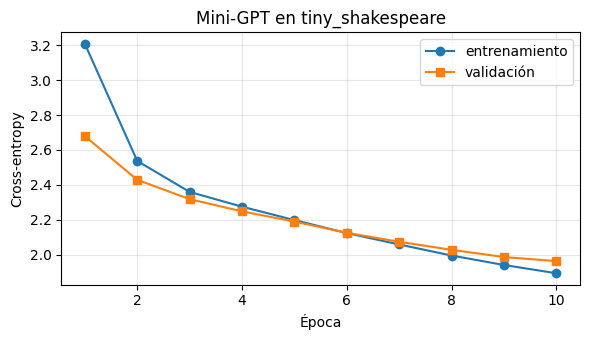

Tokens evaluados N = 111488
Pérdida media de validación = 1.9626
Perplejidad de validación = 7.118


In [5]:
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, EPOCHS+1), train_hist, 'o-', label='entrenamiento')
plt.plot(range(1, EPOCHS+1), val_hist, 's-', label='validación')
plt.xlabel('Época'); plt.ylabel('Cross-entropy'); plt.title('Mini-GPT en tiny_shakespeare')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig('curva_perdida.png', dpi=120); plt.show()

# Perplejidad = exp( (1/N) sum_t L_t )  sobre todos los tokens de validación
val_loss, N = eval_loss(val_data)
perplexity = math.exp(val_loss)
print(f'Tokens evaluados N = {N}')
print(f'Pérdida media de validación = {val_loss:.4f}')
print(f'Perplejidad de validación = {perplexity:.3f}')
assert 3.5 <= perplexity <= 8.0, 'Perplejidad fuera del rango esperado (3.5-8.0)'

## Task 1.3 — Funciones de muestreo (desde cero)

Las tres reciben los **logits crudos** $z\in\mathbb{R}^{V}$ del último paso y devuelven el índice del siguiente token.

In [6]:
def sample_greedy(logits):
    # w* = argmax_i z_i  (determinista)
    return int(torch.argmax(logits))

def sample_top_k(logits, k, temperature):
    # 1) z/tau   2) conservar los k mayores, resto = -inf   3) softmax   4) muestrear
    z = logits / temperature
    kth = torch.topk(z, k).values[-1]                       # k-ésimo mayor valor
    z = torch.where(z < kth, torch.full_like(z, float('-inf')), z)
    probs = torch.softmax(z, dim=-1)                        # P(w_i)=exp(z_i/tau)/sum_j exp(z_j/tau)
    return int(torch.multinomial(probs, 1))

def sample_top_p(logits, p, temperature):
    # 1) softmax(z/tau)  2) ordenar desc.  3) incluir tokens hasta que la prob. acumulada supere p
    # 4) renormalizar  5) muestrear
    probs = torch.softmax(logits / temperature, dim=-1)
    sp, si = torch.sort(probs, descending=True)
    cum = torch.cumsum(sp, dim=0)
    # se conserva el token si la acumulada ANTES de él aún no alcanza p (siempre queda al menos 1)
    keep = (cum - sp) < p
    sp = sp * keep
    sp = sp / sp.sum()
    return int(si[torch.multinomial(sp, 1)])

# Pruebas rápidas
z = torch.tensor([2.0, 1.0, 0.5, -1.0, -3.0])
print('greedy:', sample_greedy(z))
print('top-k(k=2) muestras:', sorted({sample_top_k(z, 2, 1.0) for _ in range(200)}), '(solo {0,1})')
print('top-p(p=0.7) muestras:', sorted({sample_top_p(z, 0.7, 1.0) for _ in range(200)}))
print('probs(z):', torch.softmax(z, 0).numpy().round(3))

greedy: 0
top-k(k=2) muestras: [0, 1] (solo {0,1})


top-p(p=0.7) muestras: [0, 1]
probs(z): [0.607 0.223 0.135 0.03  0.004]


### Prompt utilizado (Task 1)

> "Implementa un Mini-GPT a nivel de carácter con PyTorch puro (sin `nn.MultiheadAttention`), reutilizando `layer_norm`, el positional encoding y la máscara causal de mi proyecto de la Semana 6. Entrénalo en `tiny_shakespeare` (vocabulario de 65 caracteres, split 90/10, `block_size=128`, `d_model=128`, 4 cabezas, 3 capas), grafica la pérdida y calcula la perplejidad de validación. Implementa desde cero los muestreos greedy, top-k y top-p con temperatura."

**Por qué funcionó:** fijó el marco (PyTorch puro, código base a reutilizar) y dio hiperparámetros y métricas concretos, lo que permitió verificarlos con `assert` (65 caracteres, perplejidad entre 3.5 y 8.0).

## Task 2.1 — Generación carácter a carácter

In [7]:
@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, **kwargs):
    # Generación autorregresiva: en cada paso se toman los logits de la ÚLTIMA posición,
    # se elige el siguiente carácter con la estrategia y se agrega al contexto (ventana de BLOCK_SIZE).
    model.eval()
    ids = encode(prompt)
    for _ in range(max_new_tokens):
        ctx = torch.tensor([ids[-BLOCK_SIZE:]])
        logits = model(ctx)[0][0, -1]
        if strategy == 'greedy':   nxt = sample_greedy(logits)
        elif strategy == 'top_k':  nxt = sample_top_k(logits, **kwargs)
        elif strategy == 'top_p':  nxt = sample_top_p(logits, **kwargs)
        else: raise ValueError(strategy)
        ids.append(nxt)
    return decode(ids)

CONFIGS = {
    'A': ('greedy', {}),
    'B': ('top_k', dict(k=5,  temperature=0.7)),
    'C': ('top_k', dict(k=50, temperature=1.0)),
    'D': ('top_p', dict(p=0.70, temperature=0.7)),
    'E': ('top_p', dict(p=0.95, temperature=1.0)),
}
PROMPT = 'ROMEO:'
torch.manual_seed(123)
samples = {}
for name, (strat, kw) in CONFIGS.items():
    print('=' * 70); print(f'Configuración {name}: {strat} {kw}'); print('=' * 70)
    samples[name] = []
    for i in range(5):
        # 200 caracteres generados (además del prompt)
        out = generate(PROMPT, 200, strat, **kw)
        samples[name].append(out)
        print(f'--- muestra {name}{i+1} ---'); print(out); print()

Configuración A: greedy {}


--- muestra A1 ---
ROMEO:
The so the so the the the here the the the the the
The so the the the the the the the the the the the
The the the the the the the the the the the the the
That the the the the the the the the the the 



--- muestra A2 ---
ROMEO:
The so the so the the the here the the the the the
The so the the the the the the the the the the the
The the the the the the the the the the the the the
That the the the the the the the the the the 



--- muestra A3 ---
ROMEO:
The so the so the the the here the the the the the
The so the the the the the the the the the the the
The the the the the the the the the the the the the
That the the the the the the the the the the 



--- muestra A4 ---
ROMEO:
The so the so the the the here the the the the the
The so the the the the the the the the the the the
The the the the the the the the the the the the the
That the the the the the the the the the the 



...

--- muestra E1 ---
ROMEO:
Or be so, for the bleave will of a slite;
That you salf, shoou, mugger edvikig hing of crave to catn.

Excard:
Butt, not this a lish provere grouge ond death?

KINGHCHELAS:
Hark whow wars e, reset:
I



--- muestra E2 ---
ROMEO:
By gearder:
And is them yelp aposter weelver
Of is rothigh, fourst in theirsoved, and at bat ther;
In not naiciad. For Yourd the rears.

MELICIONGA:
I all hour trust to my hangead and a hand and
Thou



--- muestra E3 ---
ROMEO:
Thought him all him primp, hert beed a not-leed,
Esonce forthant to god myseps, are the wharing,
Morn's it this mardaung up hell your heald.

FRICIRHAF:
Se ston e the be your lecuar, but boung prick.



--- muestra E4 ---
ROMEO:
If death unce nis bid lords
To be let leaw coult her espeaither dearsiong thy
Pailtile: a stakess and the a suk thou of
Hathing onsodss the stealse son's cound upoch
Come, go him he'd spop.
Band your



--- muestra E5 ---
ROMEO:
Godster, thou therok and lord frost;
Hour were moriend by a of oille?

BUTULOLIUS:
Stall of thou with hath own, yenoun: are do and
That peit old pleon bload preal I him
Rold of farreacen's groord; of



In [8]:
# Métrica cuantitativa de diversidad/repetición para apoyar el análisis (Task 2.2)
def stats(txts):
    gen = [t[len(PROMPT):] for t in txts]
    uniq_chars = np.mean([len(set(g)) for g in gen])
    # fracción de trigramas repetidos dentro de la muestra
    rep = np.mean([1 - len({g[i:i+3] for i in range(len(g)-2)}) / (len(g)-2) for g in gen])
    words = [w for g in gen for w in g.split()]
    vocab_ok = np.mean([w.strip(".,;:!?'\"-").lower() in VOCAB_REAL for w in words if w.strip(".,;:!?'\"-")])
    return uniq_chars, rep, vocab_ok
import re
VOCAB_REAL = set(w.lower() for w in re.findall(r"[A-Za-z']+", text))
print(f"{'cfg':4}{'chars únicos':>14}{'trigramas repetidos':>22}{'% palabras reales':>20}")
for n in CONFIGS:
    u, r, v = stats(samples[n]); print(f'{n:4}{u:14.1f}{r:22.2%}{v:20.2%}')

cfg   chars únicos   trigramas repetidos   % palabras reales
A             10.0                89.39%             100.00%
B             29.6                35.15%              86.61%
C             38.2                 7.78%              53.12%
D             26.2                41.52%              93.47%
E             38.4                10.40%              59.36%


### Prompt utilizado (Task 2)

> "Con el modelo entrenado, escribe `generate(prompt, max_new_tokens, strategy, **kwargs)` y genera 5 muestras de 200 caracteres desde `"ROMEO:"` para las configuraciones A–E (greedy, top-k 5/0.7, top-k 50/1.0, top-p 0.70/0.7, top-p 0.95/1.0). Luego ayúdame a analizar las muestras: por qué greedy se repite, cómo cambian k y τ, y dónde el modelo está seguro o inseguro en E."

**Por qué funcionó:** definió la firma de la función y la tabla exacta de configuraciones, y pidió el análisis después de generar, de modo que las respuestas se basan en las muestras reales y en métricas de diversidad.